In [39]:
from collections import deque
import random
from xml.parsers.expat import model
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import copy

import torch.nn.functional as F
import torch
# Run this at the very top of your script
torch.set_num_threads(8)

In [40]:
from sac import SACAgent,ReplayBuffer

In [41]:

from pathlib import Path

import gym
from stable_baselines3 import PPO, SAC


# Need it to register the custom environment
import drone_2d_custom_gym_env
from gym.vector import AsyncVectorEnv, SyncVectorEnv

In [42]:
#training loop


total_steps=180000
buffer_capacity=int(1e6)
start_steps=100# 10000 steps for exploration
update_after=100
update_every=1
batch_size=256





# Select the algorithm to train: ppo or sac
ALGO = "self_sac"

# Select the environment case to train on: 1 or 2
CASE_ID = 1

CASES = {
    1: {"initial_throw": True, "initial_force": 5000, "initial_rotation_force": 600,"wind":None,"wind_magnitude":100.0},
    2: {"initial_throw": True, "initial_force": 12000, "initial_rotation_force": 1500,"wind":None,"wind_magnitude":100.0},
    3: {"initial_throw": True, "initial_force": 5000, "initial_rotation_force": 600,"wind": "Uniform","wind_magnitude":100.0},
    4: {"initial_throw": True, "initial_force": 12000, "initial_rotation_force": 1500,"wind": "Uniform","wind_magnitude":100.0},
    5: {"initial_throw": True, "initial_force": 5000, "initial_rotation_force": 600,"wind": "Random","wind_magnitude":100.0},
    6: {"initial_throw": True, "initial_force": 12000, "initial_rotation_force": 1500,"wind": "Random","wind_magnitude":100.0}
}


def make_env(case_id):
    case = CASES[case_id]
    return gym.make(
        "drone-2d-custom-v0",
        render_sim=False,
        render_path=True,
        render_shade=True,
        shade_distance=70,
        n_steps=500,
        n_fall_steps=5,
        change_target=True,
        initial_throw=case["initial_throw"],
        initial_force=case["initial_force"],
        initial_rotation_force=case["initial_rotation_force"],
        wind=case["wind"],
        wind_magnitude=case["wind_magnitude"]
    )

In [ ]:
import json



In [ ]:
SEEDS = [1, 2, 3]

def train_seed(seed, case_id, algo):
    torch.manual_seed(seed)
    np.random.seed(seed)

    env = make_env(case_id)
    env.reset()

    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]

    agent = SACAgent(obs_dim=obs_dim, act_dim=act_dim)
    buffer = ReplayBuffer(buffer_capacity, act_dim=(act_dim,), state_dim=(obs_dim,))

    history = {
        'steps': [],
        'rewards': [],
        'lengths': [],
        'successes': []
    }

    curr_ep_reward = 0
    curr_ep_len = 0

    q_optimizer = optim.Adam(list(agent.q1.parameters()) + list(agent.q2.parameters()), lr=3e-4)
    pi_optimizer = optim.Adam(agent.actor.parameters(), lr=3e-4)
    alpha_optimizer = agent.alpha_optimizer

    obs = env.reset()
    if isinstance(obs, tuple): obs = obs[0]

    for t in range(total_steps):
        if t % 1000 == 0:
            print(f"[Seed {seed}] Step: {t} | Avg Reward: {np.mean(history['rewards']) if history['rewards'] else 0:.4f} | Avg Length: {np.mean(history['lengths']) if history['lengths'] else 0:.4f}")

       
        if t < start_steps:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                obs_tensor = torch.as_tensor(obs, dtype=torch.float32)
                action, _ = agent.actor(obs_tensor)
                action = action.detach().numpy()

        
        step_result = env.step(action)
        if len(step_result) == 4:
            next_obs, reward, done, info = step_result
        else:
            next_obs, reward, term, trunc, info = step_result
            done = term or trunc

        is_timeout = (info.get('terminal_status') == "timeout")
        real_done = float(done and not is_timeout)

        buffer.store(obs, action, reward, next_obs, real_done)

        curr_ep_reward += reward
        curr_ep_len += 1

        if done:
            history['steps'].append(t)
            history['rewards'].append(curr_ep_reward)
            history['lengths'].append(curr_ep_len)

            is_success = (info.get('terminal_status') == "success")
            history['successes'].append(1.0 if is_success else 0.0)

            curr_ep_reward, curr_ep_len = 0, 0
            obs = env.reset()
            if isinstance(obs, tuple): obs = obs[0]
        else:
            obs = next_obs

        # 3. Update
        if t >= update_after and t % update_every == 0:
            for _ in range(update_every):
                batch_numpy = buffer.uniform_sample(batch_size)
                batch = {k: torch.as_tensor(v, dtype=torch.float32) for k, v in batch_numpy.items()}

                q_optimizer.zero_grad()
                loss_critic = agent.compute_critic_loss(batch)
                loss_critic.backward()
                q_optimizer.step()

             

                pi_optimizer.zero_grad()
                loss_pi = agent.compute_actor_loss(batch)
                loss_pi.backward()
                pi_optimizer.step()

                

                alpha_optimizer.zero_grad()
                agent.compute_alpha_loss(batch, target_entropy=-act_dim).backward()
                alpha_optimizer.step()

                agent.soft_update(polyak=0.995)

    # --- SAVE MODEL ---
    MODEL_DIR = Path.cwd() / "ppo_agents"
    MODEL_DIR.mkdir(parents=True, exist_ok=True)

    torch.save({
        'actor_state_dict': agent.actor.state_dict(),
        'q1_state_dict': agent.q1.state_dict(),
        'q2_state_dict': agent.q2.state_dict(),
    }, str(MODEL_DIR / f"{algo}_agent_case{case_id}_seed{seed}.pt"))

    # --- SAVE HISTORY ---
    history_path = MODEL_DIR / f"{algo}_history_case{case_id}_seed{seed}.json"
    with open(history_path, "w") as f:
        json.dump(history, f)

    print(f"[Seed {seed}] Done. Model and history saved.")
    env.close()

    return history


def train_all_seeds():
    all_histories = {}

    for seed in SEEDS:
        print(f"\n{'='*50}")
        print(f"  Training Seed {seed}")
        print(f"{'='*50}\n")
        history = train_seed(seed, CASE_ID, ALGO)
        all_histories[seed] = history

    # Save combined history for easy plotting
    MODEL_DIR = Path.cwd() / "ppo_agents"
    combined_path = MODEL_DIR / f"{ALGO}_history_case{CASE_ID}_all_seeds.json"
    with open(combined_path, "w") as f:
        json.dump({str(k): v for k, v in all_histories.items()}, f)

    print(f"\nAll seeds done. Combined history saved to {combined_path}")
    return all_histories


# Run:


In [44]:
all_histories = train_all_seeds()


  Training Seed 1

[Seed 1] Step: 0 | Avg Reward: 0.0000 | Avg Length: 0.0000


c:\Users\ZZL\miniconda3\envs\.venv\lib\site-packages\gym\utils\passive_env_checker.py:174: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.warn(
c:\Users\ZZL\miniconda3\envs\.venv\lib\site-packages\gym\utils\passive_env_checker.py:187: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.warn(
c:\Users\ZZL\miniconda3\envs\.venv\lib\site-packages\gym\utils\passive_env_checker.py:195: UserWarning: WARN: The result returned by `env.reset()` was not a tuple of the form `(obs, info)`, where `obs` is a observation and `info` is a dictionary containing additional information. Actual type: `<class 'numpy.ndarray'>`
  logger.warn(
c:\Users\ZZL\miniconda3\envs\.venv\lib\site-packages\gym\utils\passive_env_checker.py:219: DeprecationWarnin

[Seed 1] Step: 1000 | Avg Reward: -13.4161 | Avg Length: 70.2857
[Seed 1] Step: 2000 | Avg Reward: -14.0244 | Avg Length: 74.6154
[Seed 1] Step: 3000 | Avg Reward: -14.3990 | Avg Length: 74.6667


KeyboardInterrupt: 

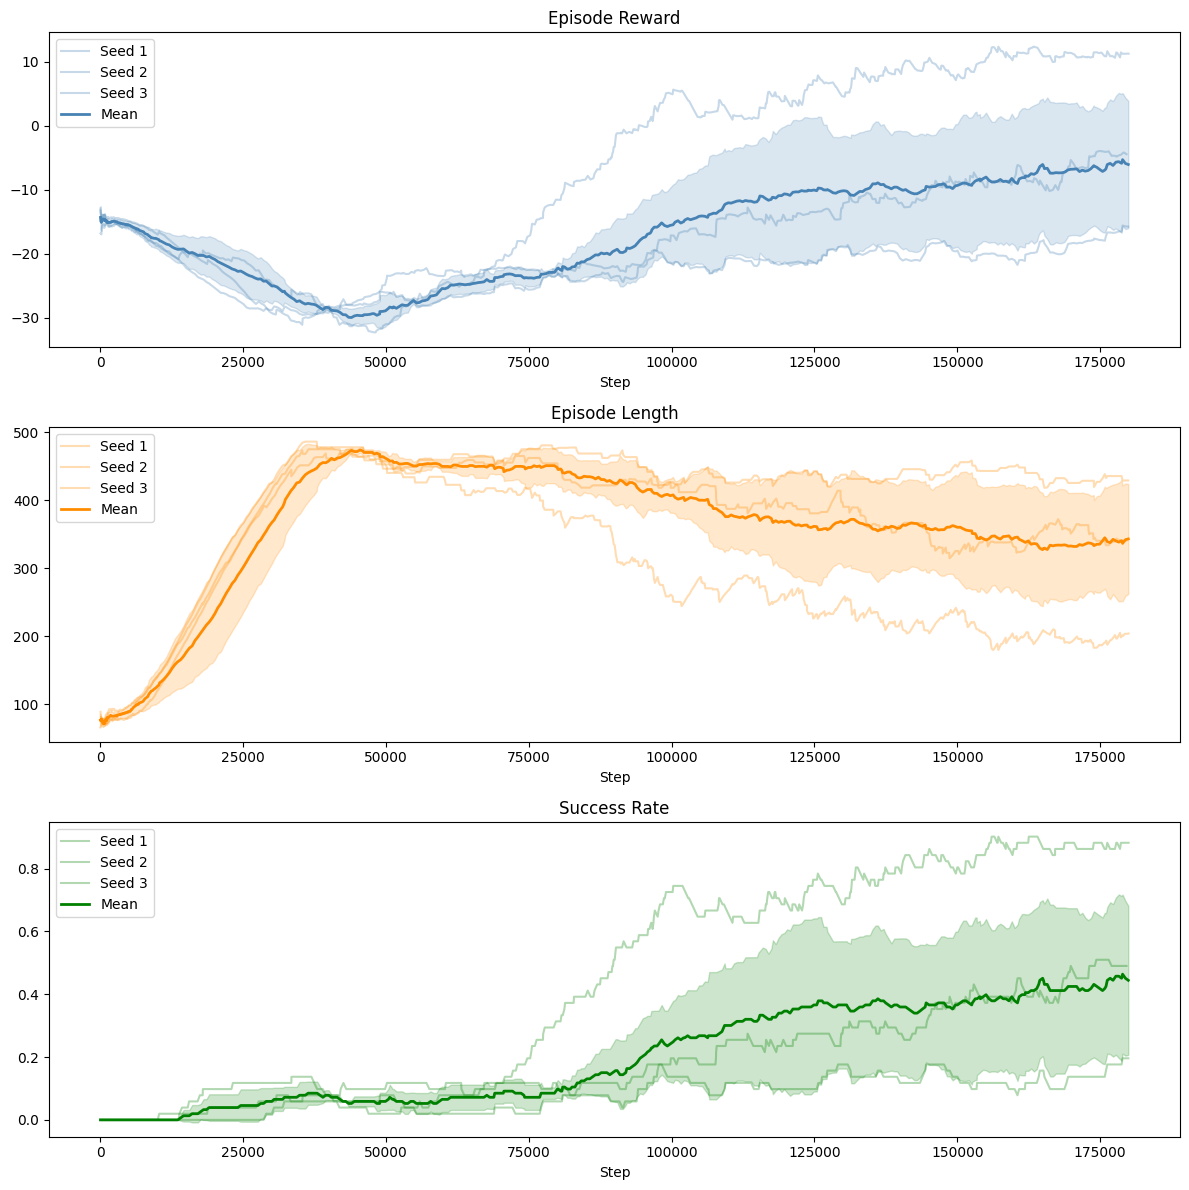

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

MODEL_DIR = Path.cwd() / "ppo_agents"

with open(MODEL_DIR / "self_sac_history_case1_all_seeds.json", "r") as f:
    all_histories = json.load(f)

def smooth(values, window=50):
    return [np.mean(values[max(0, i-window):i+1]) for i in range(len(values))]

fig, axes = plt.subplots(3, 1, figsize=(12, 12))
metrics = ['rewards', 'lengths', 'successes']
titles  = ['Episode Reward', 'Episode Length', 'Success Rate']
colors  = ['steelblue', 'darkorange', 'green']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    all_smoothed = []

    for seed, history in all_histories.items():
        smoothed = smooth(history[metric])
        all_smoothed.append(smoothed)
        ax.plot(history['steps'], smoothed, alpha=0.3, color=color, label=f"Seed {seed}")

    # Mean +/- std across seeds (interpolate to common length)
    min_len = min(len(s) for s in all_smoothed)
    clipped = np.array([s[:min_len] for s in all_smoothed])
    mean = np.mean(clipped, axis=0)
    std  = np.std(clipped, axis=0)

    # Use steps from first seed as x-axis
    steps = all_histories[list(all_histories.keys())[1]]['steps'][:min_len]
    ax.plot(steps, mean, color=color, linewidth=2, label="Mean")
    ax.fill_between(steps, mean - std, mean + std, alpha=0.2, color=color)

    ax.set_title(title)
    ax.set_xlabel("Step")
    ax.legend()

plt.tight_layout()
plt.savefig(MODEL_DIR / "self_sac_case1_all_seeds.png", dpi=150)
plt.show()